In [12]:
#	№    For copying
import os
import pandas as pd
import seaborn as sns
import geopandas as gpd
from random import randint
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from draw import Histogram, Piechart, Map, StackedBar
from helper import CountryHelper,JobHelper, SexHelper

models = ["ChatGPT","Claude","DeepSeek","Gemini"]
case_studies = ["Career Development","Family Health","Financial Literacy","Media Literacy"]


dfs = {}
for case_study in case_studies:
    these_dfs = {
        model:pd.read_excel(
            os.path.join("Case Studies",case_study,f"{case_study}.xlsx"),
            sheet_name=model,
            nrows=51, #Header (1) + Data (50)
            header=[1,2] if case_study in ['Career Development','Family Health'] else [1]
        )
        for model in models
    }
    
    for df in these_dfs.values():
        df.columns = [
            ' '.join(map(str,[    
                item for item in [(col,),col][type(col) is tuple] #Ensure col is a tuple
                if 'unnamed' not in str(item).lower() #Remove unnamed columns
            ])).strip()
            for col in df.columns
        ]
        df['Batch'] = df['Batch'].ffill().astype(int)
        
    these_dfs = {df_i:df.drop(columns=[''], errors='ignore') for df_i,df in these_dfs.items()}
    dfs[case_study] = these_dfs

for case_study in dfs:
    for model_df in dfs[case_study]:
        dfs[case_study][model_df].to_csv(os.path.join("Case Studies",case_study,f"{model_df}.csv"),index=False)


# dfs = {
#     case_study: {
#         model:pd.read_csv(os.path.join("Case Studies",case_study,f'{model}.csv'))
#         for model in models
#     }
#     for case_study in case_studies
# }

data_folder = os.path.join('Case Studies', 'Text Analysis', 'data')
if not os.path.exists(data_folder):
    os.makedirs(data_folder)
        
chizu = Map(models)
piechart = Piechart(models)
stackedBar = StackedBar(models)
histogram = Histogram(models)

sexHelper = SexHelper()
countryHelper = CountryHelper()
jobHelper = JobHelper()


from wordcloud import WordCloud, STOPWORDS
import matplotlib.patches as mpatches
from collections import Counter
from keybert import KeyBERT

kb = KeyBERT()

dfs = {
    case_study: {
        model:pd.read_csv(os.path.join("Case Studies",case_study,f'{model}.csv'))
        for model in models
    }
    for case_study in case_studies
}

dfs['Career Development'] = {
    model: df[[
            "Batch","№","Client Name","Client Sex",
            "Client Age","Client Race","Client Country of Origin",
            "Client Education", "Client Employment", "Subject","Description"
    ]].rename(columns={
        'Client Country of Origin':'Country of Residence',
        'Client Name': 'Name',
        'Client Sex': 'Sex',
        'Client Age': 'Age',
        'Client Race': 'Race',
        'Client Education': 'Education',
        'Client Employment': 'Employment'
    })
    for model,df in dfs['Career Development'].items()
}

dfs['Family Health'] = {
    model: df[[
            "Batch","№","Student Name", "Student Sex",
            "Student Age","Student Race","Student Country of Origin", "Subject Theme",
            "Student Education", "Student Employment", "Subject", "Description",
    ]].rename({
        'Student Country of Origin':'Student Country of Residence',
        'Student Name': 'Name',
        'Student Sex': 'Sex',
        'Student Age': 'Age',
        'Student Race': 'Race',
        'Student Education': 'Education',
        'Student Employment': 'Employment'
    },axis=1)
    for model,df in dfs['Family Health'].items()
}

## Text analysis

### Word Cloud

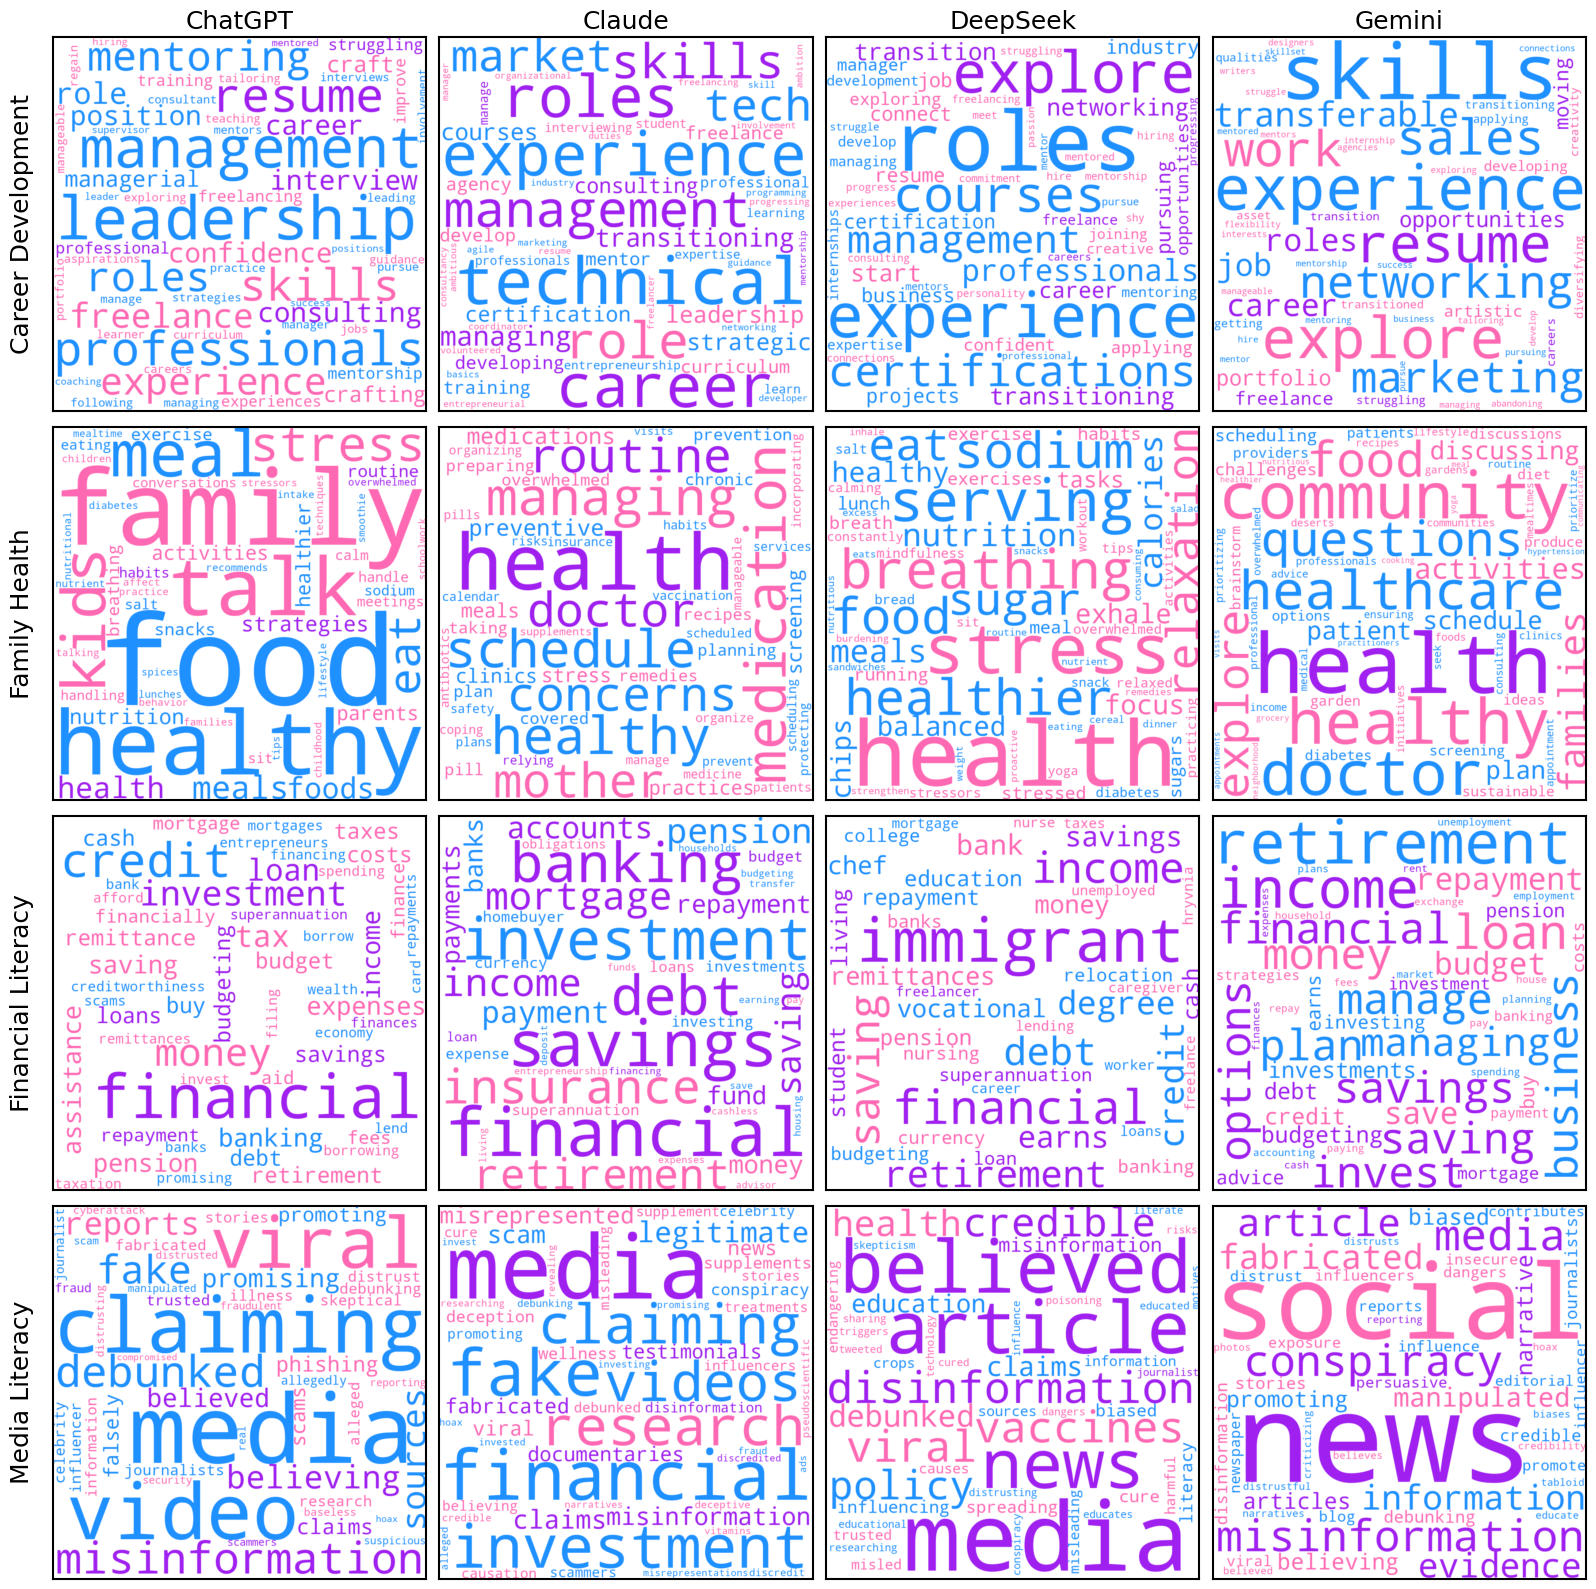

In [131]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16))


for i,dataset in enumerate(case_studies):
    for j, model in enumerate(models):
        df = dfs[dataset][model]
        df['Sex'] = df['Sex'].apply(sexHelper.sex2standard)

        female_df = df[df['Sex'] == 'Female']
        male_df = df[df['Sex'] == 'Male']

        female_txt = " ".join(female_df['Description'].dropna().astype(str))
        male_txt = " ".join(male_df['Description'].dropna().astype(str))


        #Tokenize and count frequencies, ignoring stopwords and non-alpha tokens
        def get_top_words(text, stopwords):
            freq = Counter([
                w for w in text.split()
                if w.isalpha() and w not in stopwords
            ])
            return dict(freq)

        female_top_words = get_top_words(female_txt, STOPWORDS)
        male_top_words = get_top_words(male_txt, STOPWORDS)

        # Use KeyBERT to extract the most relevant keywords in the text
        female_kw = kb.extract_keywords(docs=female_txt, top_n=40, keyphrase_ngram_range=(1, 1))
                    # kb.extract_keywords(docs=female_txt, top_n=3, keyphrase_ngram_range=(1, 2))
        male_kw = kb.extract_keywords(docs=male_txt, top_n=40, keyphrase_ngram_range=(1, 1))
                # kb.extract_keywords(docs=male_txt, top_n=3, keyphrase_ngram_range=(1, 2))

        female_kw = {word: female_top_words[word] for word, _ in female_kw if word in female_top_words}
        male_kw   = {word: male_top_words[word]   for word, _ in male_kw   if word in male_top_words}

        all_kw = {
            word: max(female_kw.get(word, 0), male_kw.get(word, 0))
            for word in set(female_kw.keys()).union(male_kw.keys())
        }

        def color_func(word, *args, **kwargs):
            in_female = word in female_kw and female_kw[word] > 0
            in_male = word in male_kw and male_kw[word] > 0

            if in_female and in_male:
                return "#a020f0"
            elif in_female:
                return "#FF69B4"
            elif in_male:
                return "#1E90FF"
            else:
                return "grey"

        wordcloud = WordCloud(
            width=1024, height=1024, collocations=False,
            background_color='white'
        ).generate_from_frequencies(all_kw)

        axs[i][j].imshow(wordcloud.recolor(color_func=color_func), interpolation='bilinear')
        
        axs[i][j].set_xticks([])
        axs[i][j].set_yticks([])
        
        for spine in axs[i][j].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
        
        axs[i][j].set_title(model if i==0 else ""     , fontsize=18)
        axs[i][j].text(-0.05, 0.5, dataset if j==0 else "", va='center', ha='right', fontsize=18, rotation=90, transform=axs[i][j].transAxes)


plt.tight_layout()
plt.savefig(os.path.join(data_folder,f"Word Cloud"), dpi=300, bbox_inches='tight')
plt.show()


### Chi-Squared

In [13]:
from scipy.stats import chi2_contingency
import scipy.stats as stats
from statsmodels.stats.contingency_tables import Table

In [30]:
dataset = "Family Health"

df = pd.concat([dfs[dataset][model].assign(model=model) for model in models], ignore_index=True)
df['Sex'] = df['Sex'].apply(sexHelper.sex2standard)
df['Subject Theme'] = df['Subject Theme'].str.strip()

contingency_table = pd.crosstab(df['Sex'],df['Subject Theme'])

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
expected_df = pd.DataFrame(expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

min_expected = expected_df.values.min()
cells_lt_5 = (expected_df.values < 5).sum()
total_cells = expected_df.size
percentage_lt_5 = (cells_lt_5 / total_cells) * 100
print(f"min_expected: {min_expected}")
print(f"cells_lt_5: {cells_lt_5}")
print(f"percentage_lt_5: {percentage_lt_5}")

if min_expected < 1:
    print("Warning: At least one cell has an expected frequency < 1. Chi-Squared is likely invalid.")
elif percentage_lt_5 > 20:
     print("Warning: More than 20% of cells have expected frequencies < 5. Chi-Squared results might be unreliable.")
else:
     print("Expected frequencies seem adequate for Chi-Squared (check rule of thumb details).")

print(f"\nChi-Squared Test Results:")
print(f"  Chi-Squared Statistic: {chi2:.4f}")
print(f"  P-value: {p_chi2:.4f}")
print(f"  Degrees of Freedom: {dof}")
# print("  Expected Frequencies Table:")
# print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))
print("-" * 30)


proportions_by_sex = contingency_table.apply(lambda r: r/r.sum(), axis=1)
print("\nInterpretation:")
print("  Compare the proportions across the rows (for each sex).")
print("  For example, if the proportion for 'Female' in 'Classification A' is much higher than for 'Male',")
print("  it suggests females are more likely to be in Classification A compared to males.")
proportions_by_sex.round(3)



min_expected: 0.025
cells_lt_5: 16
percentage_lt_5: 53.333333333333336

Chi-Squared Test Results:
  Chi-Squared Statistic: 16.4131
  P-value: 0.5637
  Degrees of Freedom: 18
------------------------------

Interpretation:
  Compare the proportions across the rows (for each sex).
  For example, if the proportion for 'Female' in 'Classification A' is much higher than for 'Male',
  it suggests females are more likely to be in Classification A compared to males.


Subject Theme,Chronic Disease Management,Communication & Healthcare,Medication Management,Mental Health & Stress Management,Nutrition & Healthy Eating,Parenting & Child Health,Physical Activity & Exercise,Preventive Health & Checkups,Sleep,Specific Topics & Behaviors
Sex,,,,,,,,,,
Female,0.096,0.064,0.032,0.287,0.149,0.085,0.117,0.128,0.000,0.043
Male,0.105,0.057,0.029,0.190,0.200,0.048,0.114,0.171,0.048,0.038
Unknown,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000


### Fisher's Exact Test

In [20]:
odds_ratio, p_value = stats.fisher_exact(contingency_table)

print(f"\nExact Test Results:")
print(f"  P-value: {p_value:.4f}")
print("-" * 30)

alpha = 0.05

print("Interpretation of Exact Test:")
if p_value < alpha:
    print(f"  The exact test p-value ({p_value:.4f}) is less than the significance level ({alpha}).")
    print("  We reject the null hypothesis.")
    print("  Conclusion: There is a statistically significant association between Sex and Classification.")
    print("  This means the distribution of classifications is significantly different between males and females.")

    # --- To see *where* the association lies, examine proportions ---
    print("\nTo see WHERE the association lies, examine proportions within each Sex:")
    print("\nInterpretation:")
    print("  Compare the proportions across the rows (for each sex).")
    print("  For example, if the proportion for 'Female' in 'Classification X' is much higher than for 'Male',")
    print("  it suggests females are more likely to be in Classification X compared to males.")

else:
    print(f"  The exact test p-value ({p_value:.4f}) is greater than or equal to the significance level ({alpha}).")
    print("  We fail to reject the null hypothesis.")
    print("  Conclusion: There is no statistically significant association between Sex and Classification in this data.")
    print("  This means the distribution of classifications is not significantly different between males and females.")


print(f"\nExact Test Results:")
print(f"  P-value: {p_value:.4f}")
print("-" * 30)

proportions_by_sex = contingency_table.apply(lambda r: r/r.sum(), axis=1)
proportions_by_sex.round(3)



Exact Test Results:
  P-value: 0.5615
------------------------------
Interpretation of Exact Test:
  The exact test p-value (0.5615) is greater than or equal to the significance level (0.05).
  We fail to reject the null hypothesis.
  Conclusion: There is no statistically significant association between Sex and Classification in this data.
  This means the distribution of classifications is not significantly different between males and females.

Exact Test Results:
  P-value: 0.5615
------------------------------


Subject Theme,Chronic Disease Management,Chronic Disease Management,Communication & Healthcare,Communication & Healthcare,Medication Management,Mental Health & Stress Management,Nutrition & Healthy Eating,Parenting & Child Health,Physical Activity & Exercise,Preventive Health & Checkups,Sleep,Sleep,Specific Topics & Behaviors
Sex,,,,,,,,,,,,,
Female,0.096,0.00,0.064,0.00,0.032,0.287,0.149,0.085,0.117,0.128,0.000,0.00,0.043
Male,0.095,0.01,0.048,0.01,0.029,0.190,0.200,0.048,0.114,0.171,0.038,0.01,0.038
Unknown,0.000,0.00,0.000,0.00,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.00,0.000


### Applying Fisher's Exact Test for each model

In [138]:
final_tables = {}
alpha = 0.05

for model in models:
    df = dfs[dataset][model]
    df['Sex'] = df['Sex'].apply(sexHelper.sex2standard)
    contingency_table = pd.crosstab(df['Sex'],df['Subject Theme'])
    odds_ratio, p_value = stats.fisher_exact(contingency_table)

    print(f"{model}'s p-value: {p_value}")
    final_tables[model] = contingency_table.apply(lambda r: r/r.sum(), axis=1).round(3)


df = pd.concat([
    final_tables[model].reset_index().assign(model=model) for model in models
], ignore_index=True)

df = df[['Sex', 'model'] + [col for col in df.columns if col not in ['Sex', 'model']]]

#Reorder rows so that for each model, Male appears first, then Female
df['Sex'] = pd.Categorical(df['Sex'], categories=['Male', 'Female'], ordered=True)
df = df.sort_values(['model', 'Sex']).reset_index(drop=True)
df

ChatGPT's p-value: 0.0291
Claude's p-value: 0.3143
DeepSeek's p-value: 0.0136
Gemini's p-value: 0.651


Subject Theme,Sex,model,Celebrity & Entertainment Misinformation,Climate Change & Environmental Misinformation,Conspiracy Theories (Broad/Overarching),Cultural & Historical Misinformation,Deepfake & Technology-Driven Deception,Financial Scams & Investment Deception,Health & Medical Misinformation,Political & Government Misinformation,Social & Identity-Based Misinformation,"Product, Brand, & Consumer Misinformation"
0,Male,ChatGPT,0.080,0.120,0.08,0.000,0.24,0.240,0.000,0.200,0.040,NaN
1,Female,ChatGPT,0.040,0.080,0.12,0.040,0.08,0.200,0.320,0.040,0.080,NaN
2,Male,Claude,0.040,0.160,0.16,0.040,0.04,0.320,0.120,0.080,NaN,0.040
3,Female,Claude,0.000,0.120,0.04,0.040,0.00,0.200,0.400,0.120,NaN,0.080
4,Male,DeepSeek,0.043,0.261,NaN,0.000,NaN,0.130,0.217,0.304,0.000,0.043
5,Female,DeepSeek,0.037,0.000,NaN,0.037,NaN,0.037,0.481,0.222,0.037,0.148
6,Male,Gemini,NaN,0.080,0.16,0.040,0.08,0.080,0.160,0.200,0.120,0.080
7,Female,Gemini,NaN,0.080,0.04,0.040,0.08,0.000,0.320,0.120,0.200,0.120


In [139]:
id_vars = ['Sex', 'model']
value_vars = [col for col in df.columns if col not in ['Subject'] + id_vars]

df_melted = pd.melt(df, id_vars=id_vars, value_vars=value_vars, var_name='Theme', value_name='Proportion')
df_melted['Theme'] = df_melted['Theme'].str.replace(' \(Broad/Overarching\)', '', regex=False)

df_pivot = df_melted.pivot_table(index=['Theme', 'Sex'], columns='model', values='Proportion', aggfunc='first')

model_order = ['ChatGPT', 'Claude', 'DeepSeek', 'Gemini']
existing_cols = [col for col in model_order if col in df_pivot.columns]
df_pivot = df_pivot[existing_cols]
df_pivot


model                                                 ChatGPT  Claude  \
Theme                                         Sex                       
Celebrity & Entertainment Misinformation      Male       0.08    0.04   
                                              Female     0.04    0.00   
Climate Change & Environmental Misinformation Male       0.12    0.16   
                                              Female     0.08    0.12   
Conspiracy Theories (Broad/Overarching)       Male       0.08    0.16   
                                              Female     0.12    0.04   
Cultural & Historical Misinformation          Male       0.00    0.04   
                                              Female     0.04    0.04   
Deepfake & Technology-Driven Deception        Male       0.24    0.04   
                                              Female     0.08    0.00   
Financial Scams & Investment Deception        Male       0.24    0.32   
                                              Female     0.20    0.20   
Health & Medical Misinformation               Male       0.00    0.12   
                                              Female     0.32    0.40   
Political & Government Misinformation         Male       0.20    0.08   
                                              Female     0.04    0.12   
Product, Brand, & Consumer Misinformation     Male        NaN    0.04   
                                              Female      NaN    0.08   
Social & Identity-Based Misinformation        Male       0.04     NaN   
                                              Female     0.08     NaN   

model                                                 DeepSeek  Gemini  
Theme                                         Sex                       
Celebrity & Entertainment Misinformation      Male       0.043     NaN  
                                              Female     0.037     NaN  
Climate Change & Environmental Misinformation Male       0.261    0.08  
                                              Female     0.000    0.08  
Conspiracy Theories (Broad/Overarching)       Male         NaN    0.16  
                                              Female       NaN    0.04  
Cultural & Historical Misinformation          Male       0.000    0.04  
                                              Female     0.037    0.04  
Deepfake & Technology-Driven Deception        Male         NaN    0.08  
                                              Female       NaN    0.08  
Financial Scams & Investment Deception        Male       0.130    0.08  
                                              Female     0.037    0.00  
Health & Medical Misinformation               Male       0.217    0.16  
                                              Female     0.481    0.32  
Political & Government Misinformation         Male       0.304    0.20  
                                              Female     0.222    0.12  
Product, Brand, & Consumer Misinformation     Male       0.043    0.08  
                                              Female     0.148    0.12  
Social & Identity-Based Misinformation        Male       0.000    0.12  
                                              Female     0.037    0.20

c:\Users\Gabriel_Freeze\Desktop\gender\draw.py:870: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.94])


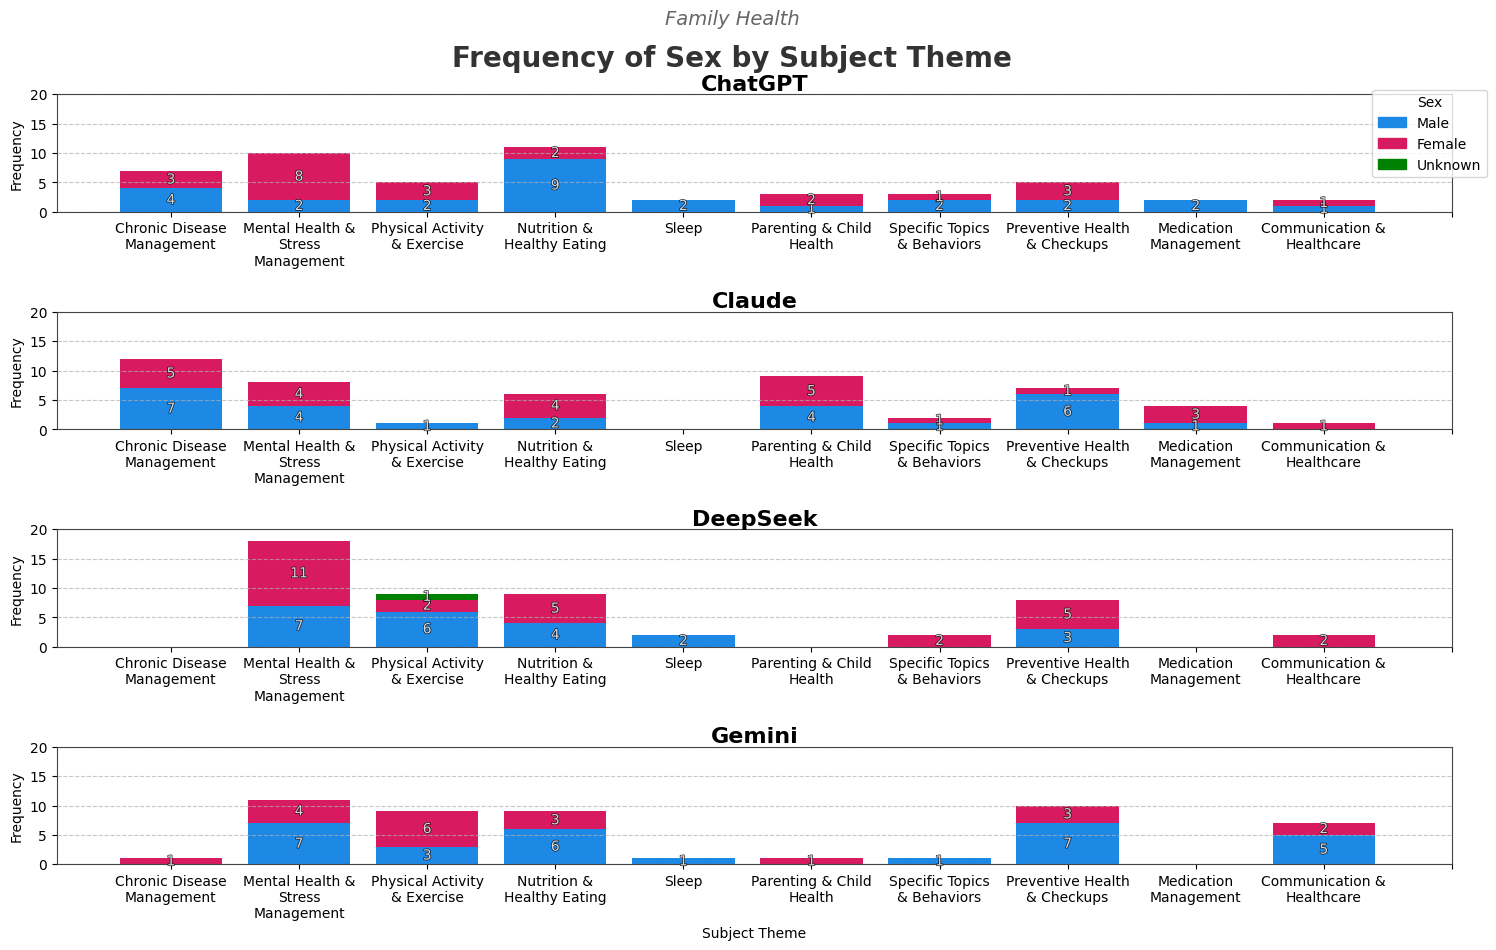

c:\Users\Gabriel_Freeze\Desktop\gender\draw.py:870: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.94])


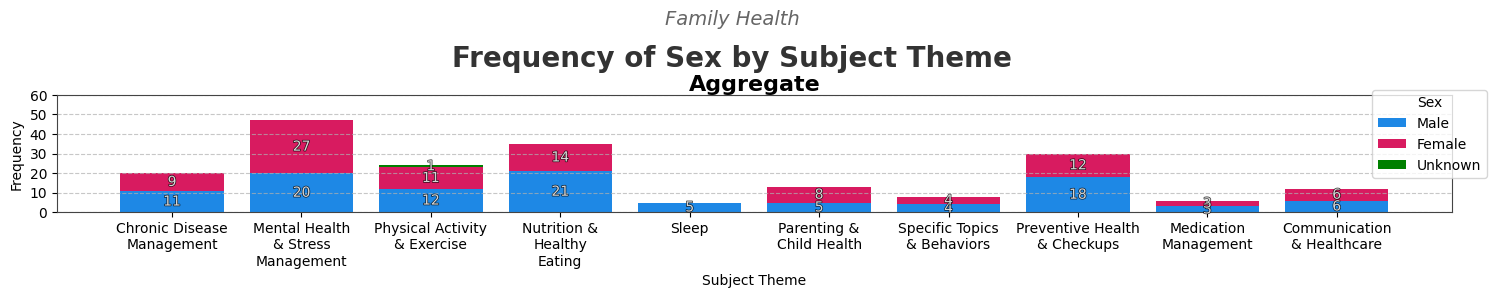

In [33]:
df = pd.concat([dfs[dataset][model].assign(model=model) for model in models], ignore_index=True)
df['Sex'] = df['Sex'].apply(sexHelper.sex2standard)
df['Subject Theme'] = df['Subject Theme'].str.strip()

#Helps with text squeezing
df['Subject Theme'] = df['Subject Theme'].str.replace(
    r'Conspiracy Theories \(Broad/Overarching\)', 'Conspiracy Theories', regex=True
)
df['Subject Theme'] = df['Subject Theme'].str.replace(
    r'Identity-Based', 'Identity Based', regex=True
)
df['Subject Theme'] = df['Subject Theme'].str.replace(
    r'Technology-Driven', 'Technology Driven', regex=True
)

df['Sex'] = df['Sex'].apply(sexHelper.sex2standard)
plt = stackedBar.draw(
    df=df,x='Subject Theme',stacked_hue='Sex', grid=True,
    space=0.85, ylim=20, ystep=5,bar_labels=True,
    txt_width=16,  figsize=(18,10), dataset=dataset
)

plt.savefig(os.path.join(data_folder,f"Gender and Subject Theme (Stacked Bar Chart) - {dataset}"), dpi=300, bbox_inches='tight')
plt.show()

plt = stackedBar.draw(
    df=df,x='Subject Theme',stacked_hue='Sex', grid=True,
    space=0.85, ylim=60, ystep=10,bar_labels=True, aggregate=True,
    txt_width=15,  figsize=(18,10), dataset=dataset
)

plt.savefig(os.path.join(data_folder,f"Gender and Subject Theme (Stacked Bar Chart) - Aggregate"), dpi=300, bbox_inches='tight')
plt.show()